No dynamic parameter subfolders found — using static calibration parameters
No Control
+-------------+---------------------------------------------+
| Quantity    | Result                                      |
+=============+=============================================+
| Velocity    | MAPE 58.06%, RMSE 17.68                     |
| Density     | MAPE 33.85%, RMSE 9.10                      |
| Flow        | MAPE 52.89%, RMSE 1751.24                   |
| Travel Time | 562.15 veh-hr vs 549.26 veh-hr (MAPE 2.29%) |
+-------------+---------------------------------------------+
Optimized VSLs
Saved to fig_new/optimal_vsl.png


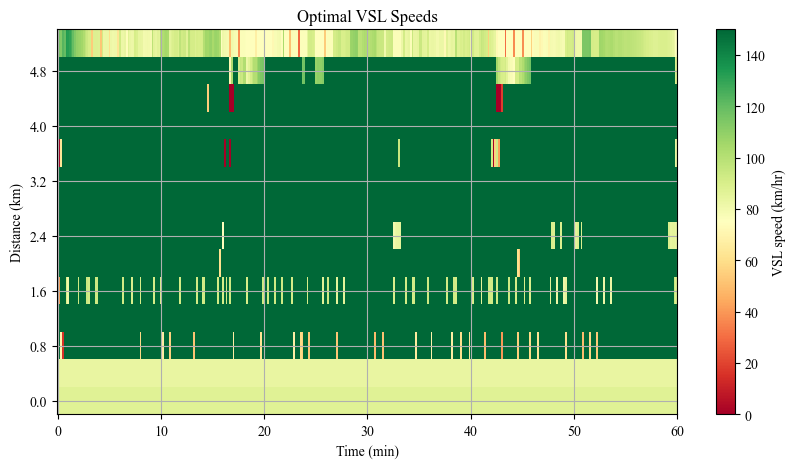

In [30]:
import sys, os, pathlib

REPO_DIR = pathlib.Path(os.path.dirname(os.path.abspath(os.getcwd())))
sys.path.insert(0, str(REPO_DIR / "src"))

from traffic_sim import METANET_Simulator
from viz import Plotter, colored
from tabulate import tabulate
from sim_types import *

# Setup freeway info
from data_loader import Freeway

freeway = Freeway(freeway="i24", date="11_30", L=0.4, num_segments=14, time_step=10/3600, time_steps=360, start_time=0.0)
start_time_step = freeway.start_time_step

# Read in the data
CONSTRAINT = None # or "speed_lb", "hold_length", "safety_sweep"
speed_lb = 0
assert(CONSTRAINT is not None or speed_lb == 0)
calibration_id = "calibration_static/fixed_ramping" # default: "calibration_static/fixed_ramping"
calibration_interval = None # None if static, else interval in time steps

p_data, q_data, v_data, lane_cts, data_inflow, downstream_density, p_init, v_init \
             = freeway.load_real_data()
results_path = freeway.results_path(calibration_id, calibration_interval, CONSTRAINT)
model_params = freeway.get_params(calibration_id, calibration_interval)

lane_dict: lane_map = {i: lane_count for i, lane_count in enumerate(lane_cts)}

print(f"{colored('No Control', 'bold', 'yellow')}")

simulator = METANET_Simulator(T=freeway.time_step, l=freeway.L, params=model_params, lanes=lane_dict, real_data=True)
p_sim, v_sim, _, _ = simulator.run_with_history(
  demand = data_inflow[start_time_step:],
  downstream_density = downstream_density[start_time_step:],
  init_traffic_state = MetanetState(p_init, v_init, data_inflow[start_time_step], 0)
)
p_sim: time_space = p_sim[:-1, :]
v_sim: time_space = v_sim[:-1, :]

q_sim = v_sim * p_sim * lane_cts

def _mape(y_true, y_pred): return np.mean(np.abs((y_true - y_pred) / y_true) * 100)
def _rmse(y_true, y_pred): return np.sqrt(np.mean((y_true - y_pred) ** 2))
gt_tt, metanet_tt = (freeway.time_step * freeway.L * (np.sum(rhos * lane_cts[np.newaxis,:])) for rhos in [p_data, p_sim])

print(tabulate(({
   qt: f"MAPE {_mape(y, y_pred):.2f}%, RMSE {_rmse(y, y_pred):.2f}" 
   for qt, y, y_pred in [("Velocity", v_data, v_sim), ("Density", p_data, p_sim), ("Flow", q_data, q_sim)]
   } | { "Travel Time": f"{gt_tt:.2f} veh-hr vs {metanet_tt:.2f} veh-hr (MAPE {abs(gt_tt - metanet_tt) / gt_tt * 100:.2f}%)"
    }).items(), headers=("Quantity", "Result"), tablefmt="outline"))

# plot optimized VSL

print(f"{colored('Optimized VSLs', 'bold', 'yellow')}")

path_id = f"optimal_vsl_{speed_lb}" if CONSTRAINT == "speed_lb" else f"optimal_vsl"
optimal_vsl: np.ndarray = np.load(results_path / f'{path_id}.npy')

v_free_extended = np.tile(model_params['v_free'], (optimal_vsl.shape[0], 1))
optimal_vsl = np.where(optimal_vsl > v_free_extended, 150, optimal_vsl)
p = Plotter(1, 1)
p.fig.colorbar(p[0].imshow(optimal_vsl.T, cmap='RdYlGn', aspect='auto', interpolation='none', vmin=0, vmax=model_params['v_free'].max()),
  label='VSL speed (km/hr)')
p[0] = {'title': 'Optimal VSL Speeds', 'xlabel': 'Time (min)', 'ylabel': 'Distance (km)',
        'xticks': np.arange(0, freeway.time_steps+1, 60), 'xticklabels': (np.arange(0, (freeway.time_steps+1) * freeway.time_step * 60, 60 * freeway.time_step * 60)).astype(int),
        'yticks': np.arange(0, freeway.num_segments, 2), 'yticklabels': np.round(np.arange(0, freeway.num_segments*freeway.L, 2*freeway.L), 2)}
p[0].invert_yaxis()
p[0].grid()
p.savefig(REPO_DIR / "fig_new" / "optimal_vsl.png")
print(f"Saved to {colored('fig_new/optimal_vsl.png', 'green')}")


In [ ]:
CHECKPOINTS = 16

free_vsl = np.full_like(optimal_vsl, 150)
segment_checkpoints = np.rint(
    np.linspace(0, freeway.num_segments, CHECKPOINTS)
).astype(int)

vsls = []
for end_segment in segment_checkpoints:
    vsl = free_vsl.copy()
    vsl[:, :end_segment] = optimal_vsl[:, :end_segment]
    vsls.append(vsl)
    
p_s, v_s, _, tts_s = zip(*(simulator.run_with_history(
    demand = data_inflow[start_time_step:],
    downstream_density = downstream_density[start_time_step:],
    init_traffic_state = MetanetState(p_init, v_init, data_inflow[start_time_step], 0),
    vsl_speeds = vsl
  ) for vsl in vsls))


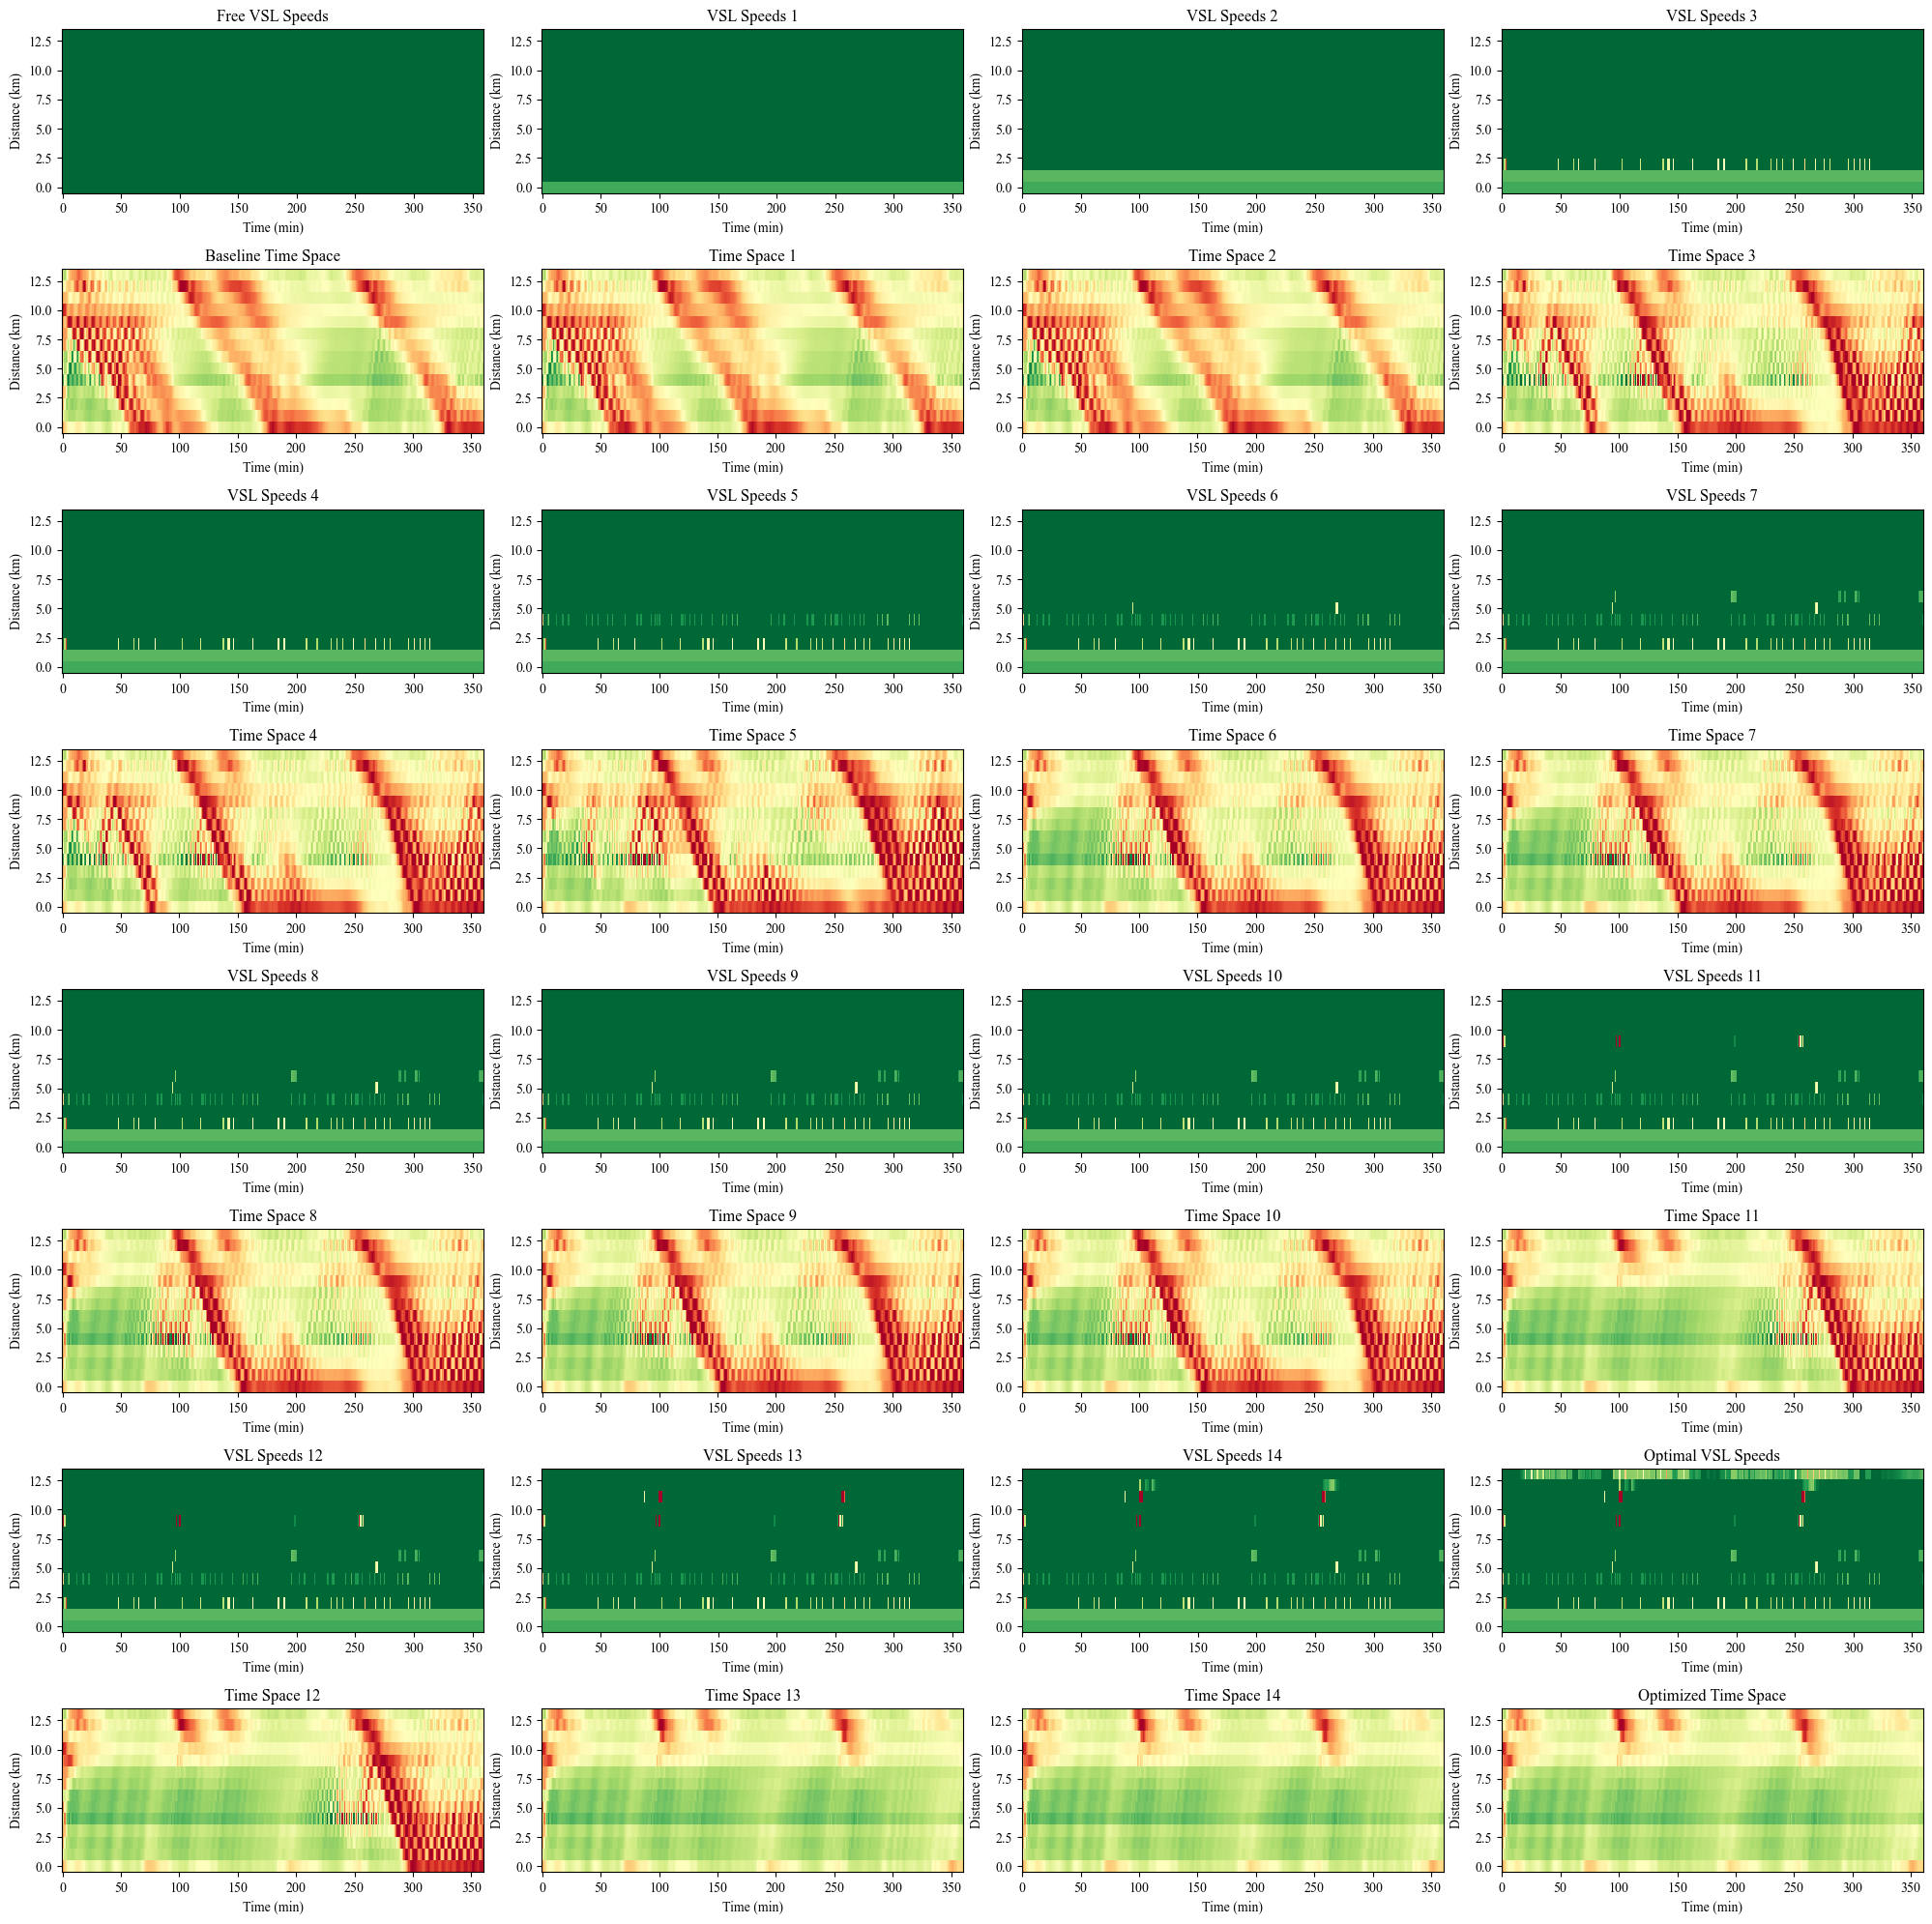

In [82]:
BATCHES = 4

p = Plotter(2 * BATCHES, CHECKPOINTS//BATCHES, figsize=(5 * CHECKPOINTS//BATCHES, 5 * BATCHES))

for b in range(BATCHES):
    for i, vsl in enumerate(vsls[b*CHECKPOINTS//BATCHES:(b+1)*CHECKPOINTS//BATCHES]):
        p[i+b*2*CHECKPOINTS//BATCHES].imshow(vsl.T, cmap='RdYlGn', aspect='auto', interpolation='none', vmin=0, vmax=max(v_data.max(), v_sim.max()))
        p[i+b*2*CHECKPOINTS//BATCHES] = {'title': 'Free VSL Speeds' if i == b == 0 else 'Optimal VSL Speeds' if b == BATCHES-1 and i == CHECKPOINTS//BATCHES-1 else f'VSL Speeds {b*CHECKPOINTS//BATCHES+i}', 'xlabel': 'Time (min)', 'ylabel': 'Distance (km)'}
        p[i+b*2*CHECKPOINTS//BATCHES].invert_yaxis()

    for i, vsl in enumerate(v_s[b*CHECKPOINTS//BATCHES:(b+1)*CHECKPOINTS//BATCHES]):
        p[i+b*2*CHECKPOINTS//BATCHES+CHECKPOINTS//BATCHES].imshow(vsl.T, cmap='RdYlGn', aspect='auto', interpolation='none', vmin=0, vmax=max(v_data.max(), v_sim.max()))
        p[i+b*2*CHECKPOINTS//BATCHES+CHECKPOINTS//BATCHES] = {'title': 'Baseline Time Space' if i == b== 0 else 'Optimized Time Space' if b == BATCHES-1 and i == CHECKPOINTS//BATCHES-1 else f'Time Space {b*CHECKPOINTS//BATCHES+i}', 'xlabel': 'Time (min)', 'ylabel': 'Distance (km)'}
        p[i+b*2*CHECKPOINTS//BATCHES+CHECKPOINTS//BATCHES].invert_yaxis()

p.show()